In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import skops.io as sio
from utils import ASSETS_DIR

In [ ]:
dataframe = pd.read_csv(f'{ASSETS_DIR}/seeds_17/train_17.csv')
dataframe.head()
dataframe.info()
dataframe.describe()
X = dataframe.drop(columns=['label'])

<class 'pandas.DataFrame'>
RangeIndex: 87447 entries, 0 to 87446
Columns: 514 entries, Unnamed: 0 to label
dtypes: float64(512), int64(2)
memory usage: 342.9 MB


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,503,504,505,506,507,508,509,510,511,label
count,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,...,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000,87447.000000
mean,54653.938694,0.679975,0.850259,0.445302,2.227789,0.402597,0.151053,0.786470,0.951524,1.446862,...,1.293948,0.069452,1.361071,0.855361,0.746845,0.792396,0.944721,1.012217,1.949626,1.678731
std,31562.613348,0.534569,0.468268,0.376930,0.649802,0.389442,0.248264,0.378930,0.581268,0.564965,...,0.648942,0.127874,0.750139,0.430801,0.545587,0.444399,0.752955,0.492305,0.822979,1.357813
min,0.000000,0.000000,0.000000,0.000000,0.066647,0.000000,0.000000,0.000000,0.000000,0.006846,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27279.000000,0.250314,0.495862,0.142100,1.780031,0.123569,0.001202,0.514109,0.518648,1.035906,...,0.807908,0.000856,0.817781,0.536851,0.333032,0.466066,0.357107,0.652407,1.367641,0.000000
50%,54657.000000,0.570663,0.815795,0.363874,2.218535,0.297941,0.040660,0.758862,0.886628,1.406275,...,1.233636,0.020944,1.253624,0.789820,0.645225,0.716539,0.770680,0.968773,1.940507,2.000000
75%,82012.500000,0.997719,1.155025,0.661558,2.655040,0.558997,0.190332,1.020626,1.302472,1.812082,...,1.717501,0.080100,1.778544,1.105982,1.044182,1.039858,1.355421,1.318595,2.509346,3.000000
max,109308.000000,4.149904,3.881930,3.237006,5.540229,4.305758,2.839259,3.651450,5.015615,4.146867,...,5.150039,2.531964,5.546824,3.502565,4.659133,3.861927,6.237524,4.545686,5.901646,3.000000


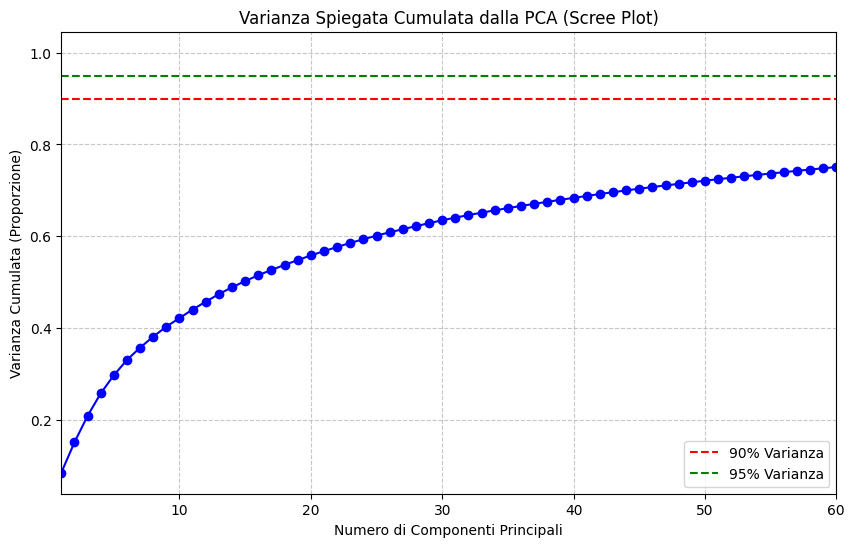

In [ ]:
# 1. Standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)

# 2. Inizializza la PCA SENZA specificare il numero di componenti.
# In questo modo calcolerà tutte le 512 componenti (o min(n_samples, n_features)).
pca = PCA()
pca.fit(X_train_scaled)

# 3. Estrai la proporzione di varianza spiegata da ogni singola componente
# e calcola la somma cumulativa
varianza_singola = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_singola)

# 4. Creazione del Grafico (Scree Plot)
plt.figure(figsize=(10, 6))

# Plotta la curva della varianza cumulata
plt.plot(range(1, len(varianza_cumulata) + 1), varianza_cumulata, marker='o', linestyle='-', color='b')
plt.xlim(1, 60)

# Aggiungi linee di riferimento (es. per il 90% e il 95% della varianza)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Varianza')

# Estetica del grafico
plt.title('Varianza Spiegata Cumulata dalla PCA (Scree Plot)')
plt.xlabel('Numero di Componenti Principali')
plt.ylabel('Varianza Cumulata (Proporzione)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

In [5]:
PCA_32 = PCA(n_components=32)
X_train_pca_32 = PCA_32.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 32 componenti: {PCA_32.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 32 componenti: 0.6459


In [6]:
PCA_16 = PCA(n_components=16)
X_train_pca_16 = PCA_16.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 16 componenti: {PCA_16.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 16 componenti: 0.5148


In [7]:
PCA_8 = PCA(n_components=8)
X_train_pca_8 = PCA_8.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 8 componenti: {PCA_8.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 8 componenti: 0.3807


In [8]:
PCA_4 = PCA(n_components=4)
X_train_pca_4 = PCA_4.fit_transform(X_train_scaled)
print(f'Varianza spiegata con 4 componenti: {PCA_4.explained_variance_ratio_.sum():.4f}')


Varianza spiegata con 4 componenti: 0.2569


In [ ]:

sio.dump(PCA_32, f'{ASSETS_DIR}/seeds_17/pca_32.skops')
sio.dump(PCA_16, f'{ASSETS_DIR}/seeds_17/pca_16.skops')
sio.dump(PCA_8, f'{ASSETS_DIR}/seeds_17/pca_8.skops')
sio.dump(PCA_4, f'{ASSETS_DIR}/seeds_17/pca_4.skops')   
sio.dump(scaler, f'{ASSETS_DIR}/seeds_17/scaler.skops')